# Bake-off: **weighted vs unweighted** quantile CatBoost

Both candidates are the *same* MultiQuantile CatBoost (`alpha=0.05,0.5,0.95`, cell
features, IFS-HRES → ERA5-Land **bias** as the target). The only difference is the
training sample weight:

- **W — weighted** (`w = 1 + ALPHA·tail`): upweights extreme-value days, like the old
  M3 regressor. Pushes point accuracy toward the temperature tails. Pinball@0.5 ≈ ½·MAE,
  so W's 0.50 column is essentially M3.
- **U — unweighted**: plain pinball loss — the honest 90%-band baseline.

We ship the **0.50** column as the point correction and the **0.05 / 0.95** columns as a
90% band, then judge the two cats on three axes:

1. **Point accuracy** — MAE overall and at the tails (10/90 deciles **and** the 1/99% extremes).
2. **Band coverage** — does the 90% interval actually cover 90%? Overall, per decile, at the 1% tails.
3. **Band width** — sharpness; among bands that cover, narrower wins.

The decision rests on the **weighting tension**: W should sharpen the point at the tails
but *distorts* what "90%" means (the band is then calibrated to a tail-reweighted population
— expect over-coverage in the bulk + wider intervals). U keeps coverage honest. We look at
**distributions, not just averages**: signed-error histograms, |error| tail tables, Q–Q plots
vs the raw forecast, band-width histograms, and per-cell coverage histograms.

In [1]:
import json, time, random, math
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool

BIAS_DIR  = Path('.').resolve()              # scripts/bias_study (notebook cwd)
REPO      = BIAS_DIR.parents[1]
CELLS_CSV = REPO / 'data' / 'cells.csv'
ARC_DIR   = BIAS_DIR / 'data' / 'archive-overlap'   # ERA5-Land truth
HRES_DIR  = BIAS_DIR / 'data' / 'hres-forecast'      # IFS-HRES forecast
LEDGER    = HRES_DIR / '.hres_progress.json'
ELEV      = BIAS_DIR / 'data' / 'cell_elevation.csv'

# --- variables: both extremes count in every one; center counts but less ---
VARS = [
    {'name': 'tmax',   'col': 'tmax_C',      'unit': '°C',  'nonneg': False},
    {'name': 'tmin',   'col': 'tmin_C',      'unit': '°C',  'nonneg': False},
    {'name': 'precip', 'col': 'precip_mm',   'unit': 'mm',  'nonneg': True},
    {'name': 'wind',   'col': 'wind_max_ms', 'unit': 'm/s', 'nonneg': True},
]
VALUE_COLS = [v['col'] for v in VARS]

# --- knobs ---
ALPHA      = 1.0     # most-extreme row gets (1+ALPHA)x the median row's weight (2x)
CELL_LIMIT = 500     # random sample of available cells; None = use ALL of them
SEED       = 0
ITERS      = 450     # CatBoost trees (bump to ~800 for the full run)

# --- split: blocked-in-time so EVERY season lands in both train and test for
#     every cell (a plain "most-recent 20%" holdout would test only one season
#     and couldn't score the hot/cold tails). Whole time-blocks go to test; an
#     embargo drops train rows touching a test block to stop adjacent-day leakage.
BLOCK_FREQ    = 'M'  # block unit: 'M' (month) or '2W' (two weeks)
HOLDOUT_EVERY = 5    # every Nth block -> test (~1/N of the data, spread across seasons)
EMBARGO_DAYS  = 3    # drop train rows within this many days of any test block

# --- Open-Meteo `ecmwf_ifs` forecast-model version (researched IFS changeovers
#     inside the 2024-03-01-> archive window). Used as a categorical feature. ---
FC_CHANGES = [(pd.Timestamp('2026-05-12'), '50r1'),   # IFS Cycle 50r1
              (pd.Timestamp('2024-11-12'), '49r1')]   # IFS Cycle 49r1
FC_BASE = '48r1'                                       # before 2024-11-12 (cycle 48r1)
# (Open-Meteo open-data IFS also went 0.4°->0.25° on 2024-02-01, but that's before
#  our 2024-03-01 floor, so it is constant in-window and not a useful feature here.)

def snap(c): return round(c * 10) / 10
def key_of(lat, lon): return f'{snap(lat):.1f}_{snap(lon):.1f}'
print('paths ok:', ARC_DIR.exists(), HRES_DIR.exists(), LEDGER.exists(), ELEV.exists())

paths ok: True True True True


## 1. Cell-agnostic discovery

Use the **intersection** of the files actually present in both dirs (so the set
grows automatically as more cells download). Optionally take a **random** sample
(not the first-N — those are geographically clustered) for a faster study run.

In [2]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi, dlmb = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlmb/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

arc_keys  = {p.name.removeprefix('archive_').removesuffix('.csv.gz')
             for p in ARC_DIR.glob('archive_*.csv.gz')}
hres_keys = {p.name.removeprefix('hres_').removesuffix('.csv.gz')
             for p in HRES_DIR.glob('hres_*.csv.gz')}
keys = sorted(arc_keys & hres_keys)
print(f'archive={len(arc_keys)}  hres={len(hres_keys)}  usable intersection={len(keys)}')
if CELL_LIMIT and CELL_LIMIT < len(keys):
    keys = random.Random(SEED).sample(keys, CELL_LIMIT)
    print(f'random sample -> {len(keys)} cells')

ledger = json.load(open(LEDGER))['done']     # key -> {name, hres_lat, hres_lon, hres_elevation, ...}
cells  = pd.read_csv(CELLS_CSV)
cells['key'] = [key_of(la, lo) for la, lo in zip(cells.lat, cells.lon)]
cells = cells.drop_duplicates('key').merge(pd.read_csv(ELEV), on='cell_id', how='left')
keymeta = cells.set_index('key')

rows = []
for k in keys:
    m = ledger.get(k)
    if m is None:                              # have files but no ledger meta -> skip
        continue
    lat_s, lon_s = k.split('_')
    cm = keymeta.loc[k] if k in keymeta.index else None
    rows.append({'key': k, 'lat': float(lat_s), 'lon': float(lon_s),
                 'hres_lat': m['hres_lat'], 'hres_lon': m['hres_lon'],
                 'hres_elevation': m['hres_elevation'],
                 'elevation': (cm['elevation'] if cm is not None else np.nan)})
static = pd.DataFrame(rows)
static['dist_to_hres_km'] = haversine_km(static.lat, static.lon, static.hres_lat, static.hres_lon)
static['elev_diff_m']     = static['elevation'] - static['hres_elevation']
print(f'static features for {len(static)} cells | elevation NaN: {int(static.elevation.isna().sum())}')
static.head()

archive=5592  hres=6481  usable intersection=5592
random sample -> 500 cells
static features for 500 cells | elevation NaN: 0


,key,lat,lon,hres_lat,hres_lon,hres_elevation,elevation,dist_to_hres_km,elev_diff_m
0,3.6_98.5,3.6,98.5,3.620387,98.467150,34.0,41.1,4.292846,7.1
1,31.2_120.7,31.2,120.7,31.177504,120.713440,3.0,1.6,2.809215,-1.4
2,-26.5_27.9,-26.5,27.9,-26.537786,27.883131,1553.0,1551.5,4.524445,-1.5
3,24.5_88.1,24.5,88.1,24.499120,88.076930,21.0,20.9,2.336355,-0.1
4,36.0_103.9,36.0,103.9,36.028120,103.873055,1953.0,1871.1,3.956045,-81.9


## 2. Load all four variables and join HRES↔ERA5-Land per day

Inner join on `date` keeps only the overlap window (drops the recent HRES-only
tail that has no ERA5-Land truth yet — that's exactly the serving case we can't
score). Read in parallel since it's thousands of small gzips.

In [3]:
def load_one(k):
    a = pd.read_csv(ARC_DIR / f'archive_{k}.csv.gz').rename(
        columns={c: f'era5_{c}' for c in VALUE_COLS})
    h = pd.read_csv(HRES_DIR / f'hres_{k}.csv.gz').rename(
        columns={c: f'hres_{c}' for c in VALUE_COLS})
    m = a.merge(h, on='date', how='inner')
    m['key'] = k
    return m

t0 = time.time()
with ThreadPoolExecutor(max_workers=8) as ex:
    frames = list(ex.map(load_one, static.key.tolist()))
df = pd.concat(frames, ignore_index=True).merge(static, on='key', how='left')
df['date'] = pd.to_datetime(df['date'])
# Coerce value cols to numeric: empty/coastal cells read as Arrow strings under
# pandas 3.0 and poison the column to object on concat. Blanks -> NaN (dropped later).
for p in ('era5', 'hres'):
    for c in VALUE_COLS:
        df[f'{p}_{c}'] = pd.to_numeric(df[f'{p}_{c}'], errors='coerce')
# Match prod's precip trace clamp (frontend/src/services/tieredData.ts, PRECIP_TRACE_MM=1): values < 1mm count as 0mm everywhere in the app. Apply identically to both sides before any bias/decile calc.
PRECIP_TRACE_MM = 1
for p in ('era5', 'hres'):
    col = f'{p}_precip_mm'
    df.loc[df[col] < PRECIP_TRACE_MM, col] = 0.0
print(f'long frame {df.shape}  dates {df.date.min().date()}..{df.date.max().date()}  '
      f'({time.time()-t0:.1f}s)')

long frame (386410, 18)  dates 2024-03-01..2026-05-01  (9.7s)


## 3. Shared features — seasonal phase + forecast-model version

`cos_doy`/`sin_doy` resolve the seasonal cycle (a lone cosine can't tell spring
from autumn). `fc_version` tags each day with the ECMWF IFS cycle Open-Meteo's
archive was on (the changeover dates from §0) — a categorical feature so the
model can absorb a version-dependent offset.

In [4]:
doy = df['date'].dt.dayofyear
df['cos_doy'] = np.cos(2*np.pi*doy/365.25)
df['sin_doy'] = np.sin(2*np.pi*doy/365.25)
df['season']  = (df['date'].dt.month % 12 // 3).map({0:'DJF', 1:'MAM', 2:'JJA', 3:'SON'})
fc = pd.Series(FC_BASE, index=df.index)
for ts, label in FC_CHANGES:                 # later changes applied last (override)
    fc = fc.mask(df['date'] >= ts, label)
df['fc_version'] = fc
print(df['fc_version'].value_counts().to_string())

fc_version
49r1    261482
48r1    124928


## 4. Per-variable target, extremity weights & deciles — the tail strategy

For each variable, within every `cell × season`:

- `u` = empirical percentile rank of the **ERA5-Land truth** value.
- `tail = |2·(u − 0.5)|` → **0 at the median, →1 at either extreme** (symmetric,
  so both tails count equally).
- training weight `w = 1 + ALPHA·tail` → median row 1×, most-extreme ≈ 2×.
- decile label `dec`: `low` (driest/coldest/calmest 10%), `high` (top 10%), else `mid`.
- **1%-tail label `dec1`**: `p01` (bottom 1%), `p99` (top 1%), else `mid` — the
  same idea as the deciles but at the genuine extremes (rarest hot/cold, dry/wet,
  calm/gale days). Reported alongside the 10% tails so we can see whether the
  correction holds up at 1-in-100 days, not just 1-in-10.
- target `bias = era5 − hres` (the additive correction to learn).

Rank-based (not z-score) is deliberate: precip/wind are skewed and zero-inflated,
so a z-score would mis-rank the tails; ranks put the genuine dry **and** wet (or
cold **and** hot) extremes in the tail buckets on both sides.

In [5]:
for v in VARS:
    n, col = v['name'], v['col']
    u = df.groupby(['key', 'season'])[f'era5_{col}'].rank(method='average', pct=True)
    tail = (2*(u - 0.5)).abs()
    df[f'tail_{n}'] = tail
    df[f'w_{n}']    = 1 + ALPHA*tail
    df[f'dec_{n}']  = np.where(u <= 0.1, 'low', np.where(u >= 0.9, 'high', 'mid'))
    df[f'dec1_{n}'] = np.where(u <= 0.01, 'p01', np.where(u >= 0.99, 'p99', 'mid'))  # 1% tails
    df[f'bias_{n}'] = df[f'era5_{col}'] - df[f'hres_{col}']
print('weight range:', round(df['w_tmax'].min(),2), '..', round(df['w_tmax'].max(),2))
df[['key','date','season','era5_tmax_C','hres_tmax_C','bias_tmax','tail_tmax','w_tmax','dec_tmax','dec1_tmax']].head()

weight range: 1.0 .. 2.0


,key,date,season,era5_tmax_C,hres_tmax_C,bias_tmax,tail_tmax,w_tmax,dec_tmax,dec1_tmax
0,3.6_98.5,2024-03-01,MAM,30.319000,32.4,-2.081000,0.386179,1.386179,mid,mid
1,3.6_98.5,2024-03-02,MAM,29.131001,30.0,-0.868999,0.560976,1.560976,mid,mid
2,3.6_98.5,2024-03-03,MAM,30.163000,31.5,-1.337000,0.272358,1.272358,mid,mid
3,3.6_98.5,2024-03-04,MAM,30.256001,31.8,-1.543999,0.349593,1.349593,mid,mid
4,3.6_98.5,2024-03-05,MAM,27.256001,31.1,-3.843999,0.943089,1.943089,low,mid


## 5. Split — blocked in time (all seasons in both train & test)

A naïve "hold out the most-recent 20% of dates" is wrong for a **tail** objective:
the test set would cover only one season, so the hot tail (summer) or cold tail
(winter) could sit entirely in train and never be scored. Instead we block the
timeline (monthly by default) and send **every Nth whole block** to test. Whole
blocks (not random rows) avoid the adjacent-day leakage — a cell's consecutive
days share almost the same bias — and an **embargo** drops train rows within a few
days of a test block so nothing leaks across the seam. The coverage table below
confirms all four seasons appear in **both** splits.

This is fair to all three models (M1's cell×season means and M3's `cell` feature
are populated from training rows that now span every season). Generalization to
**unseen cells** is the separate question in §10.

In [6]:
origin = df['date'].min().normalize()
if BLOCK_FREQ == 'M':
    block = (df['date'].dt.year - origin.year) * 12 + (df['date'].dt.month - origin.month)
else:                                              # '2W' -> 14-day blocks
    block = (df['date'] - origin).dt.days // 14
blocks = np.unique(block)
test_blocks = set(blocks[::HOLDOUT_EVERY])
df['is_test'] = block.isin(test_blocks)
# embargo: a train row is dropped if within EMBARGO_DAYS of any test-block date
test_dates = pd.DatetimeIndex(np.unique(df.loc[df['is_test'], 'date']))
emb = test_dates
for k in range(1, EMBARGO_DAYS + 1):
    emb = emb.union(test_dates + pd.Timedelta(days=k)).union(test_dates - pd.Timedelta(days=k))
df['is_train'] = (~df['is_test']) & (~df['date'].isin(emb))
print(f'{BLOCK_FREQ} blocks: {len(blocks)} total -> {len(test_blocks)} test  (embargo {EMBARGO_DAYS}d)')
print(f'train rows {int(df.is_train.sum()):,}   test rows {int(df.is_test.sum()):,}   '
      f'(dropped to embargo: {int((~df.is_train & ~df.is_test).sum()):,})')
print('season coverage (rows in each split):')
print(df.groupby("season").agg(train=("is_train","sum"), test=("is_test","sum")).to_string())

M blocks: 27 total -> 6 test  (embargo 3d)
train rows 282,064   test rows 89,304   (dropped to embargo: 15,042)
season coverage (rows in each split):
        train   test
season              
DJF     68320  15128
JJA     57096  29768
MAM     85400  29768
SON     71248  14640


## 7. The two quantile cats + the evaluator

In [7]:
GEO = ['elevation', 'hres_elevation', 'elev_diff_m', 'dist_to_hres_km', 'lat', 'lon']
DOY = ['cos_doy', 'sin_doy']
def hcol(n): return f"hres_{next(v['col'] for v in VARS if v['name']==n)}"
def ecol(n): return f"era5_{next(v['col'] for v in VARS if v['name']==n)}"
def feats(n, with_cell): return [hcol(n)] + GEO + DOY + ['fc_version'] + (['key'] if with_cell else [])

Q_ALPHAS = '0.05,0.5,0.95'        # each cat predicts these; sorted -> [lo, median, hi]
Q_LO, Q_MID, Q_HI = 0, 1, 2       # column indices after sorting (no quantile crossing)
CATS = {'W weighted': True, 'U unweighted': False}   # the two candidates: the ONLY diff is the weight

def fit_qcat(tr, n, weighted):
    pool = Pool(tr[feats(n, True)], tr[f'bias_{n}'], cat_features=['fc_version', 'key'],
                weight=(tr[f'w_{n}'].to_numpy() if weighted else None))
    m = CatBoostRegressor(loss_function=f'MultiQuantile:alpha={Q_ALPHAS}',
                          iterations=ITERS, depth=6, learning_rate=0.05,
                          l2_leaf_reg=3.0, random_seed=SEED, verbose=False)
    m.fit(pool)
    return m

def qcols(m, X): return np.sort(np.asarray(m.predict(X)), axis=1)  # sort -> bands never cross
def qmid(m, X):  return qcols(m, X)[:, Q_MID]                       # the 0.50 point correction

def evaluate(te, n, pred, nonneg):
    corrected = te[hcol(n)].to_numpy() + np.asarray(pred)
    if nonneg:
        corrected = np.clip(corrected, 0, None)
    resid = te[ecol(n)].to_numpy() - corrected
    dec = te[f'dec_{n}'].to_numpy()
    sel = {'low': dec=='low', 'mid': dec=='mid', 'high': dec=='high'}
    mae  = {k: float(np.abs(resid[m]).mean()) for k, m in sel.items()}
    bias = {k: float(resid[m].mean())          for k, m in sel.items()}
    # 1% extreme tails (p01 = bottom 1%, p99 = top 1%) — same idea as the deciles
    dec1 = te[f'dec1_{n}'].to_numpy()
    for lab, key in (('p01', 'low1'), ('p99', 'high1')):
        m = dec1 == lab
        mae[key]  = float(np.abs(resid[m]).mean()) if m.any() else float('nan')
        bias[key] = float(resid[m].mean())          if m.any() else float('nan')
    mae['all']   = float(np.abs(resid).mean())
    mae['tail']  = 0.5*(mae['low']  + mae['high'])    # headline: both 10% tails, equal
    mae['tail1'] = 0.5*(mae['low1'] + mae['high1'])   # both 1% tails, equal
    return {'mae': mae, 'bias': bias}

## 8. Train both cats (cached) + point-accuracy headline

In [8]:
import pickle
MODELS = BIAS_DIR / 'models'; MODELS.mkdir(exist_ok=True)
RETRAIN = False     # False = load cached cats if present; True = force a fresh fit + overwrite

# One cache file per cat, tagged by the exact cell-sample + seed (like the parent notebook).
NCELLS = int(df['key'].nunique())
TAG    = f'n{NCELLS}_s{SEED}'
def _path(cat, n): return MODELS / f'Q{cat[0]}_{n}_{TAG}.cbm'   # QW_<var>_<tag>.cbm / QU_...

R = {}     # R[var][cat] = evaluate(...) on the 0.50 point correction; R[var]['raw'] = do-nothing
M = {}     # M[var][cat] = the fitted MultiQuantile model (kept in memory for the band sections)
t0 = time.time()
for v in VARS:
    n, nn = v['name'], v['nonneg']
    sub = df.dropna(subset=[f'bias_{n}', f'w_{n}'])
    tr, te = sub[sub.is_train], sub[sub.is_test]
    R[n], M[n] = {}, {}
    stat = []
    for cat, wtd in CATS.items():
        p = _path(cat, n)
        if (not RETRAIN) and p.exists():
            m = CatBoostRegressor(); m.load_model(str(p)); stat.append(f'{cat[0]}=cache')
        else:
            m = fit_qcat(tr, n, weighted=wtd); m.save_model(str(p)); stat.append(f'{cat[0]}=trained')
        M[n][cat] = m
        R[n][cat] = evaluate(te, n, qmid(m, te[feats(n, True)]), nn)
    R[n]['raw'] = evaluate(te, n, np.zeros(len(te)), nn)
    print(f'  {n:6s} {", ".join(stat)}')
print(f'4 vars x 2 cats in {time.time()-t0:.0f}s (RETRAIN={RETRAIN}) | tag={TAG} ({NCELLS} cells, seed {SEED})')

# headline: point accuracy of the 0.50 correction vs the raw forecast (do-nothing baseline)
rows = []
for v in VARS:
    n, unit = v['name'], v['unit']
    raw = R[n]['raw']['mae']
    for cat in CATS:
        e = R[n][cat]['mae']
        rows.append({'var': f'{n} ({unit})', 'cat': cat,
                     'MAE': e['all'], 'tailMAE': e['tail'], 'tail1MAE': e['tail1'],
                     'd_all_%':   100*(1 - e['all']  / raw['all']),
                     'd_tail_%':  100*(1 - e['tail'] / raw['tail']),
                     'd_tail1_%': 100*(1 - e['tail1']/ raw['tail1'])})
acc = pd.DataFrame(rows)
print('\n== point accuracy of the 0.50 column: MAE overall / 10-90 tail / 1-99 tail; d_* = % better than raw ==')
print(acc.round(3).to_string(index=False))

  tmax   W=cache, U=cache


  tmin   W=cache, U=cache


  precip W=cache, U=cache


  wind   W=trained, U=trained
4 vars x 2 cats in 98s (RETRAIN=False) | tag=n488_s0 (488 cells, seed 0)

== point accuracy of the 0.50 column: MAE overall / 10-90 tail / 1-99 tail; d_* = % better than raw ==
        var          cat   MAE  tailMAE  tail1MAE  d_all_%  d_tail_%  d_tail1_%
  tmax (°C)   W weighted 0.757    0.873     1.030   35.128    28.883     19.961
  tmax (°C) U unweighted 0.757    0.882     1.052   35.184    28.173     18.300
  tmin (°C)   W weighted 0.778    0.904     1.097   29.557    24.450     17.169
  tmin (°C) U unweighted 0.776    0.915     1.118   29.772    23.525     15.565
precip (mm)   W weighted 2.040    6.393    14.233   11.604    -1.653    -14.608
precip (mm) U unweighted 2.026    6.585    14.709   12.228    -4.701    -18.438
 wind (m/s)   W weighted 0.514    0.682     0.970   46.192    35.581     21.563
 wind (m/s) U unweighted 0.510    0.720     1.027   46.570    31.952     16.949


## A. Point accuracy — the 0.50 correction

The 0.50 column is what actually gets served. Lower MAE is better; we read it three ways
— overall, the 10/90 decile tail (`tailMAE`), and the 1/99% extreme tail (`tail1MAE`).
Bars below break MAE out by value bucket (`low1`/`high1` are the 1% extremes), raw vs both
cats. If W's tail weighting earns its keep, it shows up as shorter `low1`/`high1` bars.

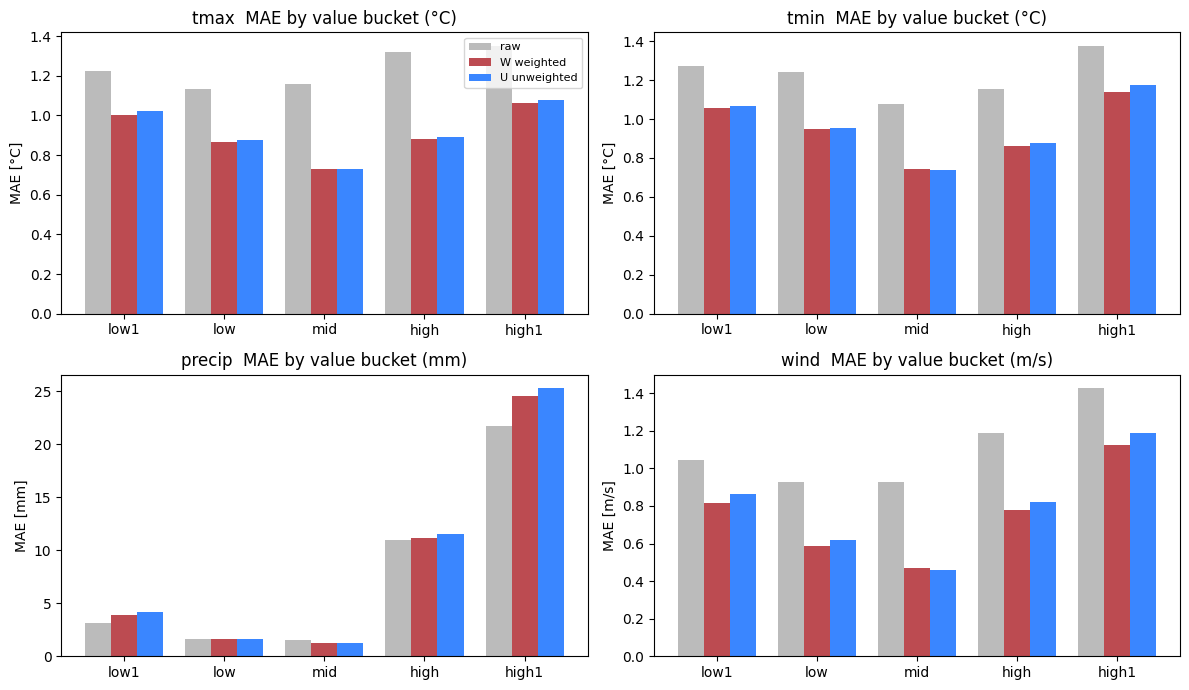

In [9]:
# MAE by value bucket: raw vs the two cats. low1/high1 = the 1% extremes the product cares about.
buckets = ['low1', 'low', 'mid', 'high', 'high1']
order   = ['raw', 'W weighted', 'U unweighted']
colors  = {'raw': '#bbb', 'W weighted': '#bc4b51', 'U unweighted': '#3a86ff'}
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, v in zip(axes.ravel(), VARS):
    n, unit = v['name'], v['unit']
    x = np.arange(len(buckets)); w = 0.26
    for j, mdl in enumerate(order):
        m = R[n][mdl]['mae']
        ax.bar(x + (j-1)*w, [m[b] for b in buckets], w, label=mdl, color=colors[mdl])
    ax.set_xticks(x); ax.set_xticklabels(buckets)
    ax.set_title(f'{n}  MAE by value bucket ({unit})'); ax.set_ylabel(f'MAE [{unit}]')
    if ax is axes[0, 0]: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

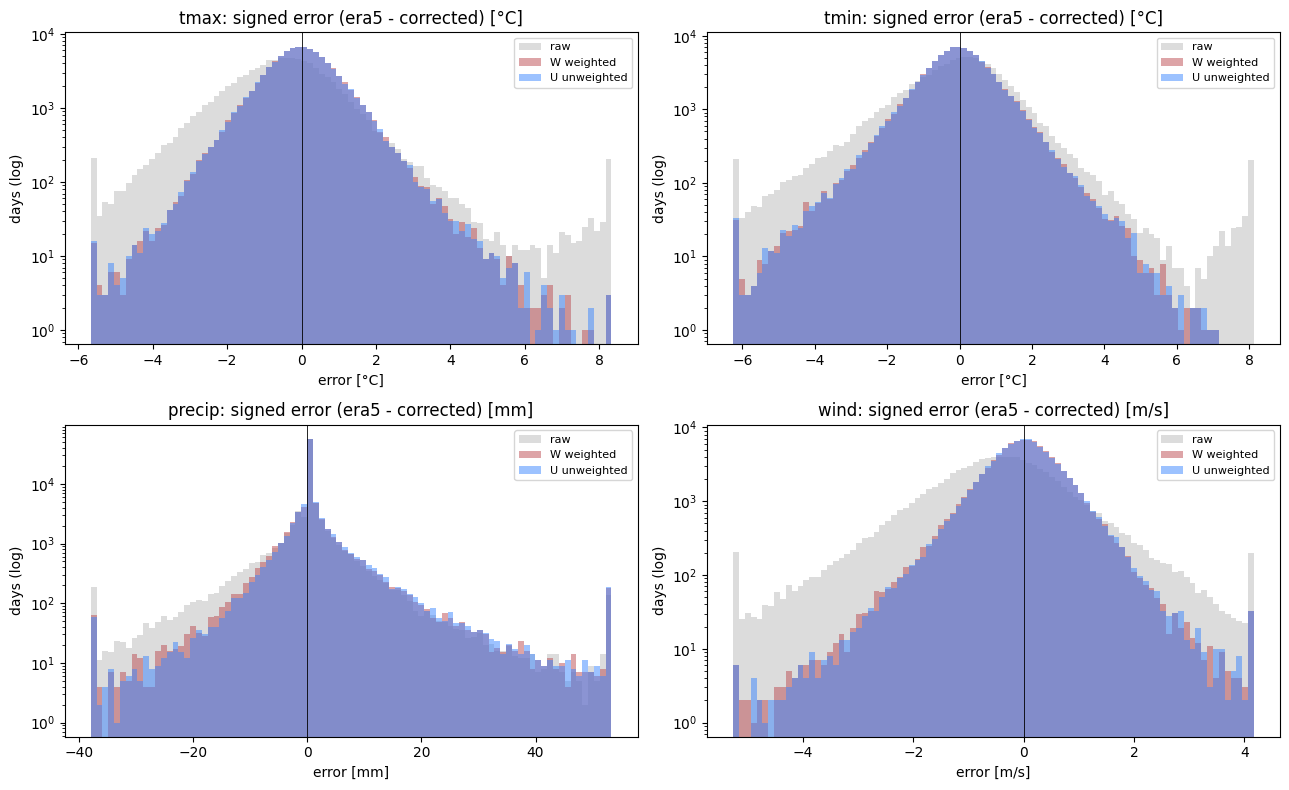

In [10]:
# Per-row test errors (era5 - corrected) for raw + both cats, kept as full distributions.
ERR = {}
for v in VARS:
    n, nn = v['name'], v['nonneg']
    te = df[df.is_test].dropna(subset=[f'bias_{n}', f'w_{n}']).copy()
    h, e = te[hcol(n)].to_numpy(), te[ecol(n)].to_numpy()
    te['err_raw'] = e - h
    for cat in CATS:
        c = h + qmid(M[n][cat], te[feats(n, True)])
        if nn: c = np.clip(c, 0, None)
        te[f'err_{cat[0]}'] = e - c               # err_W, err_U
    ERR[n] = te

# Signed-error histograms (log count) — the whole distribution, raw vs W vs U.
# Tighter + centred on 0 = better; the visible difference between cats lives in the wings.
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
ecols = {'raw': 'err_raw', 'W weighted': 'err_W', 'U unweighted': 'err_U'}
for ax, v in zip(axes.ravel(), VARS):
    n, unit = v['name'], v['unit']
    te = ERR[n]
    lo = float(min(te[c].quantile(0.002) for c in ecols.values()))
    hi = float(max(te[c].quantile(0.998) for c in ecols.values()))
    bins = np.linspace(lo, hi, 90)
    for mdl, c in ecols.items():
        ax.hist(te[c].clip(lo, hi), bins=bins, color=colors[mdl], alpha=0.5, label=mdl)
    ax.axvline(0, color='k', lw=0.6); ax.set_yscale('log')
    ax.set_title(f'{n}: signed error (era5 - corrected) [{unit}]')
    ax.set_xlabel(f'error [{unit}]'); ax.set_ylabel('days (log)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [11]:
# |error| TAILS, not averages: where the two cats differ is in the bad days.
rows = []
for v in VARS:
    n, unit = v['name'], v['unit']; te = ERR[n]
    ar, aw, au = te['err_raw'].abs(), te['err_W'].abs(), te['err_U'].abs()
    for lab, q in [('p50', .5), ('p90', .9), ('p99', .99), ('p99.9', .999)]:
        rows.append({'var': f'{n} ({unit})', 'pctile': lab,
                     'raw': ar.quantile(q), 'W': aw.quantile(q), 'U': au.quantile(q),
                     'W-U': aw.quantile(q) - au.quantile(q)})
    rows.append({'var': f'{n} ({unit})', 'pctile': 'max',
                 'raw': ar.max(), 'W': aw.max(), 'U': au.max(), 'W-U': aw.max() - au.max()})
print('== |error| tail percentiles: raw vs W vs U (W-U < 0 = weighted is tighter at that pctile) ==')
print(pd.DataFrame(rows).round(2).to_string(index=False))

== |error| tail percentiles: raw vs W vs U (W-U < 0 = weighted is tighter at that pctile) ==
        var pctile    raw      W      U   W-U
  tmax (°C)    p50   0.88   0.58   0.57  0.00
  tmax (°C)    p90   2.49   1.64   1.64 -0.00
  tmax (°C)    p99   5.03   3.13   3.13 -0.00
  tmax (°C)  p99.9   8.99   5.10   5.11 -0.02
  tmax (°C)    max  12.59  10.62  10.51  0.10
  tmin (°C)    p50   0.81   0.57   0.57  0.00
  tmin (°C)    p90   2.37   1.70   1.70  0.00
  tmin (°C)    p99   5.27   3.43   3.43  0.01
  tmin (°C)  p99.9   8.86   5.27   5.30 -0.03
  tmin (°C)    max  14.66  13.94  14.66 -0.71
precip (mm)    p50   0.00   0.00   0.00 -0.00
precip (mm)    p90   6.98   5.91   5.78  0.14
precip (mm)    p99  27.26  24.15  24.41 -0.26
precip (mm)  p99.9  70.38  69.86  70.80 -0.94
precip (mm)    max 184.26 189.59 190.78 -1.19
 wind (m/s)    p50   0.73   0.38   0.38  0.00
 wind (m/s)    p90   2.04   1.11   1.10  0.01
 wind (m/s)    p99   4.01   2.24   2.22  0.03
 wind (m/s)  p99.9   6.45   3.79 

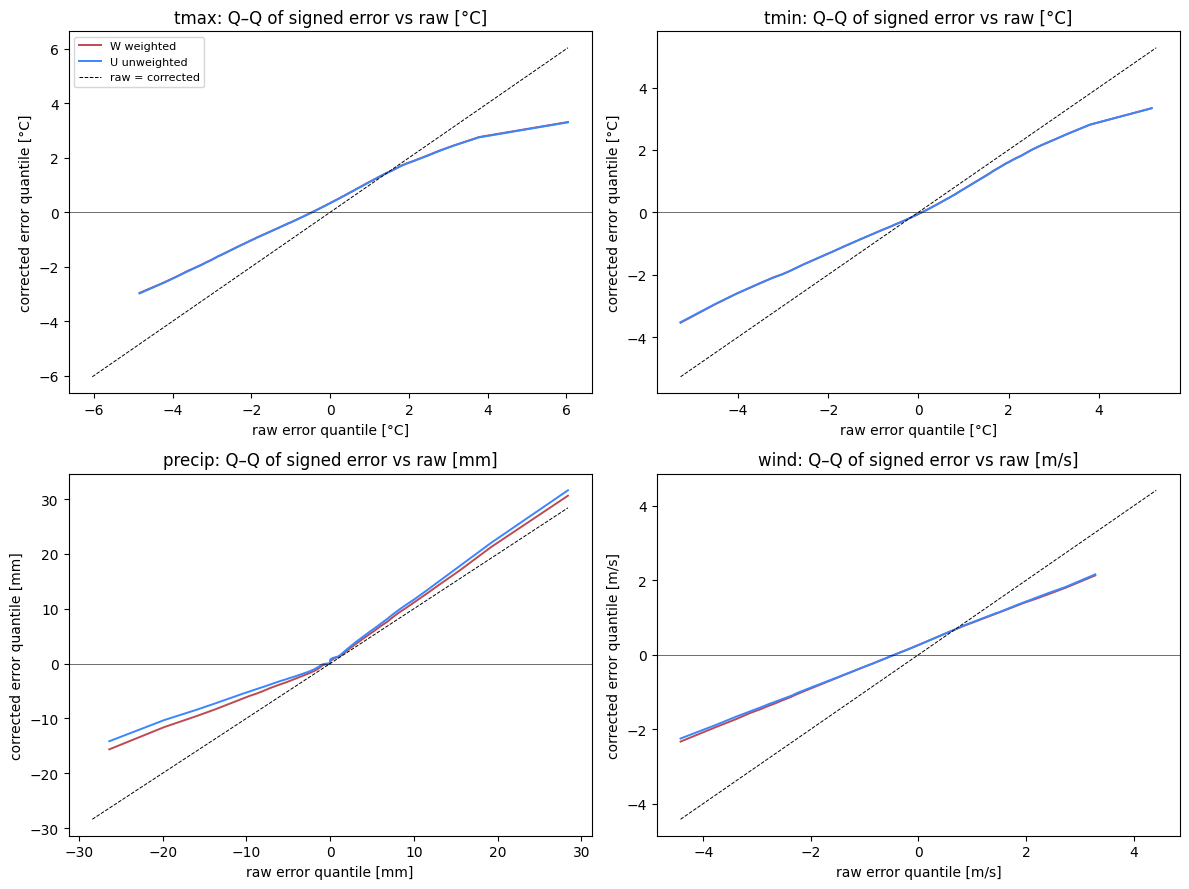

In [12]:
# Q-Q of the signed error vs the RAW forecast error: how each cat reshapes the whole
# error distribution. A flat line through 0 = errors crushed; the line tracking the dashed
# raw=corrected diagonal at the ENDS = the tail behaviour. W below U at the extremes = W
# pulls the worst days in harder (its weighting paying off there).
qs = np.linspace(0.005, 0.995, 199)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, v in zip(axes.ravel(), VARS):
    n, unit = v['name'], v['unit']; te = ERR[n]
    rq = te['err_raw'].quantile(qs).to_numpy()
    for cat, c in [('W weighted', 'err_W'), ('U unweighted', 'err_U')]:
        ax.plot(rq, te[c].quantile(qs).to_numpy(), '-', color=colors[cat], lw=1.4, label=cat)
    lim = float(np.abs(rq).max())
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.7, label='raw = corrected')
    ax.axhline(0, color='k', lw=0.4)
    ax.set_title(f'{n}: Q–Q of signed error vs raw [{unit}]')
    ax.set_xlabel(f'raw error quantile [{unit}]'); ax.set_ylabel(f'corrected error quantile [{unit}]')
    if ax is axes[0, 0]: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## B. Band coverage & C. width — the honest-90% test

Now the 0.05/0.95 columns. We score the cats' **own** bands head-to-head (no conformal
patch) on the test set: a row is *covered* if the realised bias `era5 - hres` lands inside
`[q0.05, q0.95]`. Target is 0.90. This is where the weighting tension should bite — the
prediction was that **W over-covers in the bulk and runs wider**, while **U stays near 0.90**.

In [13]:
# 90% band = [0.05, 0.95] cols. Coverage (target 0.90) + mean width, overall / per decile / 1% tails.
def band_stats(y, lo, hi, dec, dec1):
    inside = (y >= lo) & (y <= hi); width = hi - lo
    out = {'cov': float(inside.mean()), 'width': float(width.mean())}
    for d in ('low', 'mid', 'high'):
        m = dec == d
        out[f'cov_{d}'] = float(inside[m].mean()) if m.any() else float('nan')
    for lab in ('p01', 'p99'):
        m = dec1 == lab
        out[f'cov_{lab}'] = float(inside[m].mean()) if m.any() else float('nan')
    return out, inside, width

COV, WID, INSIDE = [], {}, {}
for v in VARS:
    n = v['name']; te = ERR[n]; X = te[feats(n, True)]
    y    = te[f'bias_{n}'].to_numpy()                          # band is scored on the realised bias
    dec  = te[f'dec_{n}'].to_numpy(); dec1 = te[f'dec1_{n}'].to_numpy()
    WID[n], INSIDE[n] = {}, {}
    for cat in CATS:
        q = qcols(M[n][cat], X); lo, hi = q[:, Q_LO], q[:, Q_HI]
        s, inside, width = band_stats(y, lo, hi, dec, dec1)
        s.update(var=n, cat=cat); COV.append(s)
        WID[n][cat], INSIDE[n][cat] = width, inside
C = pd.DataFrame(COV)[['var', 'cat', 'cov', 'width', 'cov_low', 'cov_mid', 'cov_high', 'cov_p01', 'cov_p99']]
print('== 90% band: coverage (target 0.90) & mean width, W vs U — overall, per decile, 1% tails ==')
print('   expect W: cov > 0.90 (esp. cov_mid) + wider; U: cov ~ 0.90 + sharper')
print(C.round(3).to_string(index=False))

== 90% band: coverage (target 0.90) & mean width, W vs U — overall, per decile, 1% tails ==
   expect W: cov > 0.90 (esp. cov_mid) + wider; U: cov ~ 0.90 + sharper
   var          cat   cov  width  cov_low  cov_mid  cov_high  cov_p01  cov_p99
  tmax   W weighted 0.894  3.145    0.842    0.907     0.829    0.790    0.734
  tmax U unweighted 0.890  3.092    0.832    0.904     0.821    0.776    0.720
  tmin   W weighted 0.894  3.188    0.848    0.908     0.809    0.780    0.645
  tmin U unweighted 0.890  3.143    0.842    0.905     0.794    0.762    0.610
precip   W weighted 0.930  9.536    0.864    0.945     0.771    0.600    0.614
precip U unweighted 0.917  8.787    0.825    0.933     0.740    0.600    0.581
  wind   W weighted 0.911  2.212    0.771    0.941     0.817    0.410    0.665
  wind U unweighted 0.900  2.140    0.724    0.937     0.787    0.359    0.634


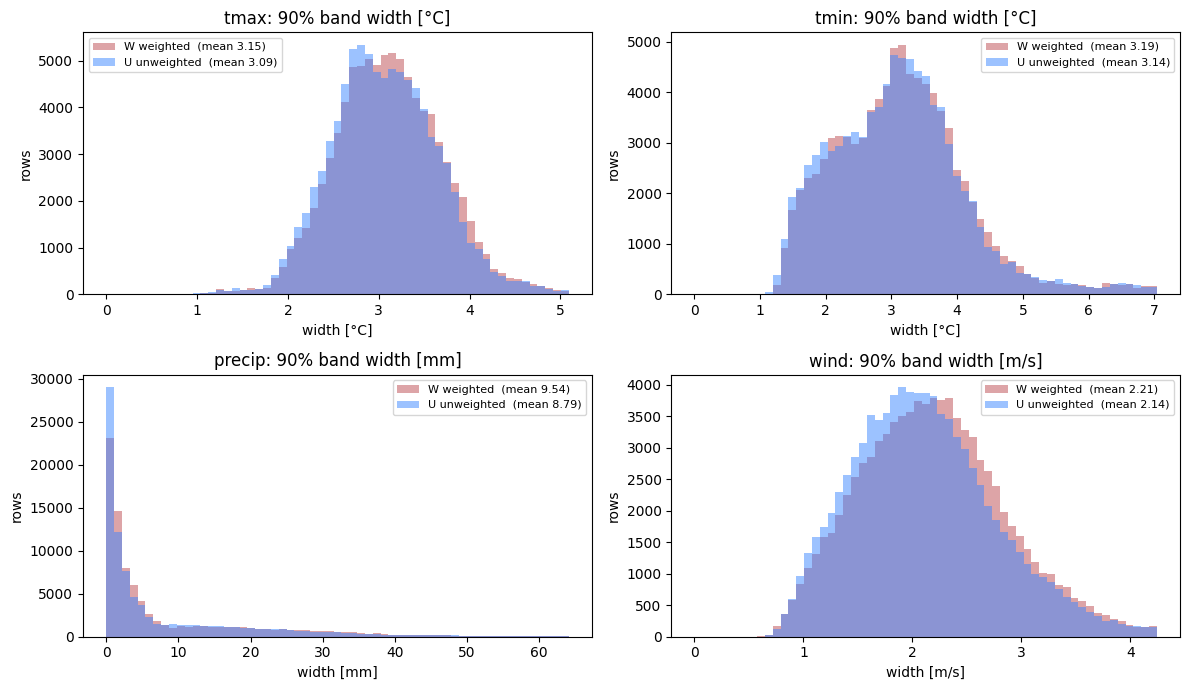

In [14]:
# Band-WIDTH distributions (not just the mean): sharpness, W vs U. Only fair to prefer the
# narrower cat where its coverage is also ≥ 0.90 (read against the table above).
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, v in zip(axes.ravel(), VARS):
    n, unit = v['name'], v['unit']
    hi = float(max(np.quantile(WID[n][c], 0.99) for c in CATS))
    bins = np.linspace(0, hi, 60)
    for cat in CATS:
        ax.hist(WID[n][cat], bins=bins, color=colors[cat], alpha=0.5,
                label=f'{cat}  (mean {WID[n][cat].mean():.2f})')
    ax.set_title(f'{n}: 90% band width [{unit}]'); ax.set_xlabel(f'width [{unit}]')
    ax.set_ylabel('rows'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

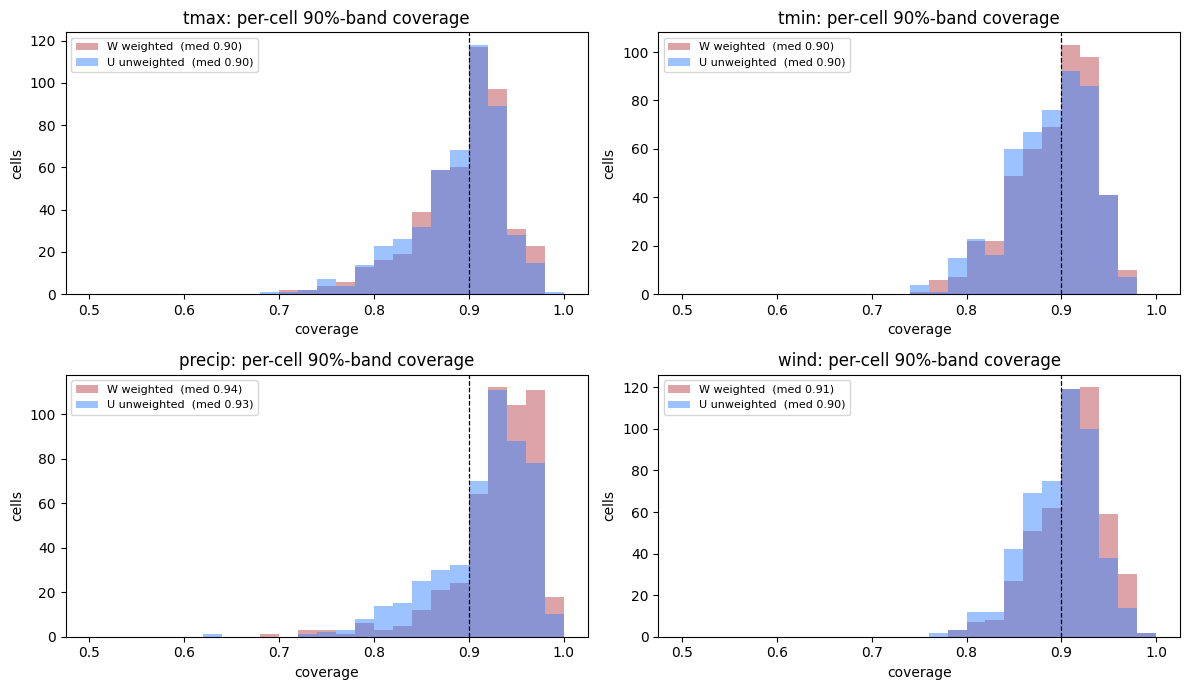

In [15]:
# Per-CELL coverage, not the global rate: how many cells does each cat leave badly
# under/over-covered? A good band sits in a tight spike on the 0.90 line; a fat left tail =
# cells the band fails. This is the coverage story the single average hides.
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, v in zip(axes.ravel(), VARS):
    n = v['name']; te = ERR[n]; keys = te['key'].to_numpy()
    for cat in CATS:
        s = pd.Series(INSIDE[n][cat]).groupby(keys).mean()
        ax.hist(s, bins=np.linspace(0.5, 1.0, 26), color=colors[cat], alpha=0.5,
                label=f'{cat}  (med {s.median():.2f})')
    ax.axvline(0.90, color='k', ls='--', lw=0.9)
    ax.set_title(f'{n}: per-cell 90%-band coverage'); ax.set_xlabel('coverage'); ax.set_ylabel('cells')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## D. Reading the bake-off — which cat ships

Put the three axes together:

- **Point (§A).** If `tailMAE` / `tail1MAE` for **W** beat **U** by a margin that matters
  operationally, the weighting earns the point. If they're within noise (likely — both
  estimate the conditional median, and W's 0.50 ≈ the old M3), the point is a wash and the
  decision falls to the band.
- **Coverage (§B).** **U** near 0.90 overall *and* per decile is the honest band. **W**
  drifting to `cov_mid > 0.90` confirms the bulk over-coverage the weighting predicts — a
  90% label that doesn't mean 90%.
- **Width (§C).** Among bands that actually cover, narrower wins. If **W** is both
  over-covering *and* wider, it's strictly dominated on the band.

**Default read:** ship **U** — honest, sharper 90% band, and a 0.50 point that's
statistically the same median. Reach for **W** only if §A shows a real, repeatable tail-MAE
win you're willing to trade calibrated coverage for. Either way the 0.05/0.95 band comes from
the same single cat — no second model to train.